## Signal definitions — update here when adding new inputs/outputs

In [14]:
INPUT_KEYS = ['grf_x', 'grf_y', 'grf_z', 'cop_x', 'cop_y', 'cop_z']
N_INPUTS   = len(INPUT_KEYS)

# OUTPUT_KEYS, N_OUTPUTS, and _labels are loaded from the test dataset in the
# 'Load test data' cell below — no need to define them here.
print(f'Inputs ({N_INPUTS}): {INPUT_KEYS}')

Inputs (6): ['grf_x', 'grf_y', 'grf_z', 'cop_x', 'cop_y', 'cop_z']


## Config — set paths and models to compare here

In [15]:
# data_dir   = 'C:\\Users\\bakel\\Desktop\\GRFMuscleModel\\Old_Young_Walking_Data\\'
# model_dir  = '..\\models\\'
data_dir  = '/Users/briankeller/Desktop/GRFMuscleModel/models/Test_Data/'
model_dir = '../models/'

# Prefix used to locate model weights and Optuna studies:
#   <model_dir>/<model_prefix>_<name>.pth   and   study <model_prefix>_<name>
model_prefix = 'Ulrich_jrf_cop_leg'

# Prefix for the test dataset file.  Defaults to model_prefix, but can be
# any dataset saved by Split_*_Dataset (including test_only splits).
# Examples:
#   test_prefix = 'Silder_OA_jrf_cop_leg'    # uses Silder_OA_jrf_cop_leg_test_only.npz
#   test_prefix = model_prefix               # uses same dataset the model was trained on
test_prefix = 'Silder_mixed_jrf_cop_leg'

optuna_db = f'sqlite:///{model_dir}optuna.db'

# Models to compare — each entry must have a matching <model_prefix>_<name>.pth
# and a corresponding Optuna study named <model_prefix>_<name> in the DB.
MODELS_TO_COMPARE = ['lstm', 'lstm_attn', 'cnn_lstm', 'transformer']

# Display names used in plots and tables (must align with MODELS_TO_COMPARE)
MODEL_LABELS = ['LSTM', 'LSTM+Attention', 'CNN-LSTM', 'Transformer']

# Plot colours (one per model)
MODEL_COLORS = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']

# Which test sample to use for single-prediction plots
SAMPLE_IDX = 0

# Subset of outputs to evaluate / plot.
# Set to a list of names drawn from OUTPUT_KEYS, or None to use all outputs.
SUBSET_KEYS = ['achilles', 'tibant', 'tibpost', 'ehl', 'edl', 'fhl', 'fdl', 'perlong', 'perbrev', 'ankle_fx', 'ankle_fy', 'ankle_fz', 'knee_fx', 'knee_fy', 'knee_fz']

# Example: SUBSET_KEYS = ['achilles', 'soleus', 'gaslat', 'gasmed', 'tibant', 'tibpost']

## Imports

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn
from sklearn.metrics import r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('Imports OK')

Imports OK


## Load test data

In [17]:
import os

# Try <test_prefix>_test_data.npz first, then <test_prefix>_test_only.npz
_candidates = [
    data_dir + f'{test_prefix}_test_data.npz',
    data_dir + f'{test_prefix}_test_only.npz',
]
_test_file = next((p for p in _candidates if os.path.exists(p)), None)
assert _test_file is not None, (
    f'No test file found for prefix "{test_prefix}". Tried:\n' +
    '\n'.join(_candidates)
)
print(f'Loading test data from: {_test_file}')

test_data = np.load(_test_file, allow_pickle=True)
X_test    = test_data['X_test']
y_test    = test_data['y_test']

# Output labels are stored in the dataset — no need to hardcode them
OUTPUT_KEYS = [str(k) for k in test_data['output_keys']]
N_OUTPUTS   = len(OUTPUT_KEYS)

# Optional human-readable display names (must match ORDER of OUTPUT_KEYS).
# Set to None to fall back to OUTPUT_KEYS.
OUTPUT_LABELS = None
_labels = OUTPUT_LABELS if OUTPUT_LABELS is not None else OUTPUT_KEYS

assert X_test.shape[2] == N_INPUTS,  f'Expected {N_INPUTS} inputs,  got {X_test.shape[2]}'
assert y_test.shape[2] == N_OUTPUTS, f'Expected {N_OUTPUTS} outputs, got {y_test.shape[2]}'

SEQ_LEN = X_test.shape[1]
print(f'X_test: {X_test.shape}   y_test: {y_test.shape}')
print(f'Outputs ({N_OUTPUTS}): {OUTPUT_KEYS}')

Loading test data from: /Users/briankeller/Desktop/GRFMuscleModel/models/Test_Data/Silder_mixed_jrf_cop_leg_test_only.npz
X_test: (1002, 100, 6)   y_test: (1002, 100, 44)
Outputs (44): ['addbrev', 'addlong', 'addmagDist', 'addmagIsch', 'addmagMid', 'addmagProx', 'bflh', 'bfsh', 'edl', 'ehl', 'fdl', 'fhl', 'gaslat', 'gasmed', 'glmax1', 'glmax2', 'glmax3', 'glmed1', 'glmed2', 'glmed3', 'glmin1', 'glmin2', 'glmin3', 'grac', 'iliacus', 'perbrev', 'perlong', 'psoas', 'recfem', 'semimem', 'semiten', 'soleus', 'tibant', 'tibpost', 'vasint', 'vaslat', 'vasmed', 'achilles', 'knee_fx', 'knee_fy', 'knee_fz', 'ankle_fx', 'ankle_fy', 'ankle_fz']


## Device + tensors

In [18]:
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_test_t   = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t   = torch.tensor(y_test, dtype=torch.float32).to(device)
print(f'Device: {device}')

Device: cpu


## Model definitions

In [19]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)


class LSTMAttentionModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_heads,
                 output_size, lstm_dropout=0.0, attn_dropout=0.0):
        super().__init__()
        self.lstm      = nn.LSTM(input_size, hidden_size, num_layers,
                                 batch_first=True,
                                 dropout=lstm_dropout if num_layers > 1 else 0.0)
        self.attention = nn.MultiheadAttention(embed_dim=hidden_size,
                                               num_heads=num_heads,
                                               dropout=attn_dropout,
                                               batch_first=True)
        self.fc        = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        return self.fc(attn_out)


class CNNLSTMModel(nn.Module):
    def __init__(self, input_size, cnn_channels, hidden_size, num_layers,
                 output_size, dropout=0.0):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_size,   cnn_channels,     kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(cnn_channels, cnn_channels * 2, kernel_size=3, padding=1),
            nn.ReLU(),
        )
        self.lstm = nn.LSTM(cnn_channels * 2, hidden_size, num_layers,
                            batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.fc   = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        cnn_out = self.cnn(x.permute(0, 2, 1))
        cnn_out = cnn_out.permute(0, 2, 1)
        lstm_out, _ = self.lstm(cnn_out)
        return self.fc(lstm_out)


class TransformerModel(nn.Module):
    def __init__(self, input_dim, output_dim, d_model, nhead,
                 num_encoder_layers, dim_feedforward, dropout):
        super().__init__()
        self.input_embedding = nn.Linear(input_dim, d_model)
        self.register_buffer('positional_encoding',
                             self._generate_positional_encoding(d_model, max_len=500))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,
                                                          num_layers=num_encoder_layers)
        self.output_layer = nn.Linear(d_model, output_dim)

    def forward(self, x):
        seq_len = x.size(1)
        x = self.input_embedding(x)
        x = x + self.positional_encoding[:, :seq_len, :]
        x = self.transformer_encoder(x)
        return self.output_layer(x)

    @staticmethod
    def _generate_positional_encoding(d_model, max_len=500):
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             -(math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)


def build_model(model_name, bp):
    """Reconstruct a model from Optuna best_params (uses N_INPUTS / N_OUTPUTS from signal defs)."""
    if model_name == 'lstm':
        return LSTMModel(N_INPUTS, bp['hidden_size'], bp['num_layers'],
                         N_OUTPUTS, bp['dropout_rate']).to(device)
    elif model_name == 'lstm_attn':
        return LSTMAttentionModel(N_INPUTS, bp['hidden_size'], bp['num_layers'],
                                  bp['num_heads'], N_OUTPUTS,
                                  bp['lstm_dropout'], bp['attn_dropout']).to(device)
    elif model_name == 'cnn_lstm':
        return CNNLSTMModel(N_INPUTS, bp['cnn_channels'], bp['hidden_size'],
                            bp['num_layers'], N_OUTPUTS, bp['dropout_rate']).to(device)
    elif model_name == 'transformer':
        return TransformerModel(N_INPUTS, N_OUTPUTS,
                                bp['d_model'], bp['num_heads'],
                                bp['num_encoder_layers'],
                                bp['ff_mult'] * bp['d_model'],
                                bp['dropout_rate']).to(device)
    else:
        raise ValueError(f'Unknown model name: {model_name}')


print('Model classes and build_model defined.')

Model classes and build_model defined.


## Load models from weights

In [20]:
criterion    = nn.MSELoss()
test_results = {}   # {model_name: {'model': ..., 'preds': np.ndarray, 'test_loss': float}}

for model_name in MODELS_TO_COMPARE:
    weight_path = model_dir + f'{model_prefix}_{model_name}.pth'
    study_name  = f'{model_prefix}_{model_name}'
    print(study_name)
    try:
        study = optuna.load_study(study_name=study_name, storage=optuna_db)
        bp    = study.best_params
        model = build_model(model_name, bp)
        model.load_state_dict(torch.load(weight_path, map_location=device, weights_only=True))
        model.eval()

        with torch.no_grad():
            preds_t   = model(X_test_t)
            test_loss = criterion(preds_t, y_test_t).item()

        test_results[model_name] = {
            'model':     model,
            'preds':     preds_t.cpu().numpy(),
            'test_loss': test_loss,
        }
        print(f'{model_name:15s}  test_loss = {test_loss:.4f}')

    except Exception as e:
        print(f'Could not load {model_name}: {e}')

Ulrich_jrf_cop_leg_lstm
lstm             test_loss = 3.8637
Ulrich_jrf_cop_leg_lstm_attn
lstm_attn        test_loss = 13.3935
Ulrich_jrf_cop_leg_cnn_lstm
cnn_lstm         test_loss = 4.1421
Ulrich_jrf_cop_leg_transformer
transformer      test_loss = 3.3572


## Subset slicing — resolves SUBSET_KEYS into eval arrays

In [21]:
# Re-run this cell whenever you change SUBSET_KEYS or reload models.
if SUBSET_KEYS is None:
    _eval_idxs   = list(range(N_OUTPUTS))
    _eval_labels = list(_labels)
else:
    unknown = [k for k in SUBSET_KEYS if k not in OUTPUT_KEYS]
    assert not unknown, f'Unknown key(s) in SUBSET_KEYS: {unknown}'
    _eval_idxs   = [OUTPUT_KEYS.index(k) for k in SUBSET_KEYS]
    _eval_labels = [_labels[i] for i in _eval_idxs]

N_EVAL     = len(_eval_idxs)
y_eval     = y_test[:, :, _eval_idxs]                                          # (samples, seq_len, N_EVAL)
preds_eval = {n: r['preds'][:, :, _eval_idxs] for n, r in test_results.items()}

print(f'Evaluating {N_EVAL} output(s): {_eval_labels}')

Evaluating 15 output(s): ['achilles', 'tibant', 'tibpost', 'ehl', 'edl', 'fhl', 'fdl', 'perlong', 'perbrev', 'ankle_fx', 'ankle_fy', 'ankle_fz', 'knee_fx', 'knee_fy', 'knee_fz']


## Eval metric helpers
All functions operate on arrays shaped `(samples, seq_len, n_outputs)` and use
`OUTPUT_KEYS` / `_labels` for printing — no hard-coded signal names.

In [22]:
def _ranges(y):
    return y.max(axis=(0, 1)) - y.min(axis=(0, 1))   # (n_outputs,)


def calc_r2_per_output(y_true, y_pred, labels=None, verbose=True):
    ss_res = np.sum((y_true - y_pred) ** 2, axis=(0, 1))
    ss_tot = np.sum((y_true - np.mean(y_true, axis=(0, 1), keepdims=True)) ** 2, axis=(0, 1))
    r2 = 1 - ss_res / ss_tot
    if verbose:
        for lbl, v in zip(labels or _labels, r2):
            print(f'  {lbl}: {v:.4f}')
    return r2


def calc_r2_overall(y_true, y_pred):
    return r2_score(y_true.flatten(), y_pred.flatten())


def calc_rmse_per_output(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=(0, 1)))


def calc_rmse_overall(y_true, y_pred):
    return np.sqrt(np.mean((y_true.flatten() - y_pred.flatten()) ** 2))


def calc_rrmse_per_output(y_true, y_pred, labels=None, verbose=True):
    rrmse = calc_rmse_per_output(y_true, y_pred) / _ranges(y_true)
    if verbose:
        for lbl, v in zip(labels or _labels, rrmse):
            print(f'  {lbl}: {v:.4f}')
    return rrmse


def calc_rrmse_overall(y_true, y_pred):
    flat_t, flat_p = y_true.flatten(), y_pred.flatten()
    return np.sqrt(np.mean((flat_t - flat_p) ** 2)) / (flat_t.max() - flat_t.min())


def calc_rrmse_weighted(y_true, y_pred):
    r = _ranges(y_true)
    rrmse = calc_rmse_per_output(y_true, y_pred) / r
    return np.sum(rrmse * r) / np.sum(r)


def calc_rmspe_overall(y_true, y_pred):
    flat_t, flat_p = y_true.flatten(), y_pred.flatten()
    return np.sqrt(np.mean(((flat_t - flat_p) / flat_t) ** 2))


def calc_mae_per_output(y_true, y_pred, labels=None, verbose=True):
    mae = np.mean(np.abs(y_true - y_pred), axis=(0, 1))
    if verbose:
        for lbl, v in zip(labels or _labels, mae):
            print(f'  {lbl}: {v:.4f}')
    return mae


def calc_mae_overall(y_true, y_pred):
    return np.mean(np.abs(y_true.flatten() - y_pred.flatten()))




print('Metric helpers defined.')

Metric helpers defined.


## Per-output metrics

In [23]:
per_output = {}   # {model_name: {'rrmse': ..., 'mae': ..., 'r2': ...}}

for model_name, pred in preds_eval.items():
    print(f'\n=== {model_name} ===')
    print('-- RRMSE per output --')
    rrmse = calc_rrmse_per_output(y_eval, pred, labels=_eval_labels)
    print('-- MAE per output --')
    mae   = calc_mae_per_output(y_eval, pred, labels=_eval_labels)
    print('-- R² per output --')
    r2    = calc_r2_per_output(y_eval, pred, labels=_eval_labels)
    per_output[model_name] = {'rrmse': rrmse, 'mae': mae, 'r2': r2}


=== lstm ===
-- RRMSE per output --
  achilles: 0.0908
  tibant: 0.1186
  tibpost: 0.1570
  ehl: 0.1113
  edl: 0.1062
  fhl: 0.1698
  fdl: 0.1701
  perlong: 0.1189
  perbrev: 0.1611
  ankle_fx: 0.0974
  ankle_fy: 0.0901
  ankle_fz: 0.0877
  knee_fx: 0.0886
  knee_fy: 0.0876
  knee_fz: 0.0778
-- MAE per output --
  achilles: 3.3214
  tibant: 0.7194
  tibpost: 1.4016
  ehl: 0.0367
  edl: 0.1628
  fhl: 0.2753
  fdl: 0.0817
  perlong: 0.5556
  perbrev: 0.1913
  ankle_fx: 2.1470
  ankle_fy: 4.6999
  ankle_fz: 0.5146
  knee_fx: 1.9392
  knee_fy: 4.1754
  knee_fz: 0.3735
-- R² per output --
  achilles: 0.8293
  tibant: 0.4443
  tibpost: 0.0211
  ehl: 0.0293
  edl: 0.0938
  fhl: 0.1342
  fdl: -0.0754
  perlong: 0.0853
  perbrev: 0.0673
  ankle_fx: 0.5748
  ankle_fy: 0.7570
  ankle_fz: 0.1886
  knee_fx: 0.5661
  knee_fy: 0.6853
  knee_fz: 0.4137

=== lstm_attn ===
-- RRMSE per output --
  achilles: 0.2381
  tibant: 0.1220
  tibpost: 0.1871
  ehl: 0.1141
  edl: 0.1068
  fhl: 0.2353
  fdl: 0.172

## Overall metrics summary

In [24]:
overall = {}   # {model_name: {metric_name: value}}

header = f'{"Model":<16}  {"MSE":>8}  {"RMSE":>8}  {"RRMSE":>8}  {"RRMSEw":>8}  {"RMSPE":>8}  {"MAE":>8}  {"R²":>8}'
print(header)
print('-' * len(header))

for model_name, pred in preds_eval.items():
    mse = nn.MSELoss()(
        torch.tensor(pred, dtype=torch.float32),
        torch.tensor(y_eval, dtype=torch.float32)
    ).item()
    m = {
        'mse':     mse,
        'rmse':    calc_rmse_overall(y_eval, pred),
        'rrmse':   calc_rrmse_overall(y_eval, pred),
        'rrmse_w': calc_rrmse_weighted(y_eval, pred),
        'rmspe':   calc_rmspe_overall(y_eval, pred),
        'mae':     calc_mae_overall(y_eval, pred),
        'r2':      calc_r2_overall(y_eval, pred),
    }
    overall[model_name] = m
    print(f'{model_name:<16}  {m["mse"]:>8.4f}  {m["rmse"]:>8.4f}  {m["rrmse"]:>8.4f}  '
          f'{m["rrmse_w"]:>8.4f}  {m["rmspe"]:>8.4f}  {m["mae"]:>8.4f}   {m["r2"]:>8.4f}')

Model                  MSE      RMSE     RRMSE    RRMSEw     RMSPE       MAE        R²
--------------------------------------------------------------------------------------
lstm                7.1445    2.6729    0.0226    0.0955   68.3972    1.3730     0.9396
lstm_attn          27.2543    5.2206    0.0442    0.1639  192.5362    2.5959     0.7695
cnn_lstm            6.9002    2.6268    0.0223    0.0951  125.1636    1.3581     0.9416
transformer         6.0432    2.4583    0.0208    0.0923  171.0270    1.3194     0.9489


## Visualization — mean ± SD across test set

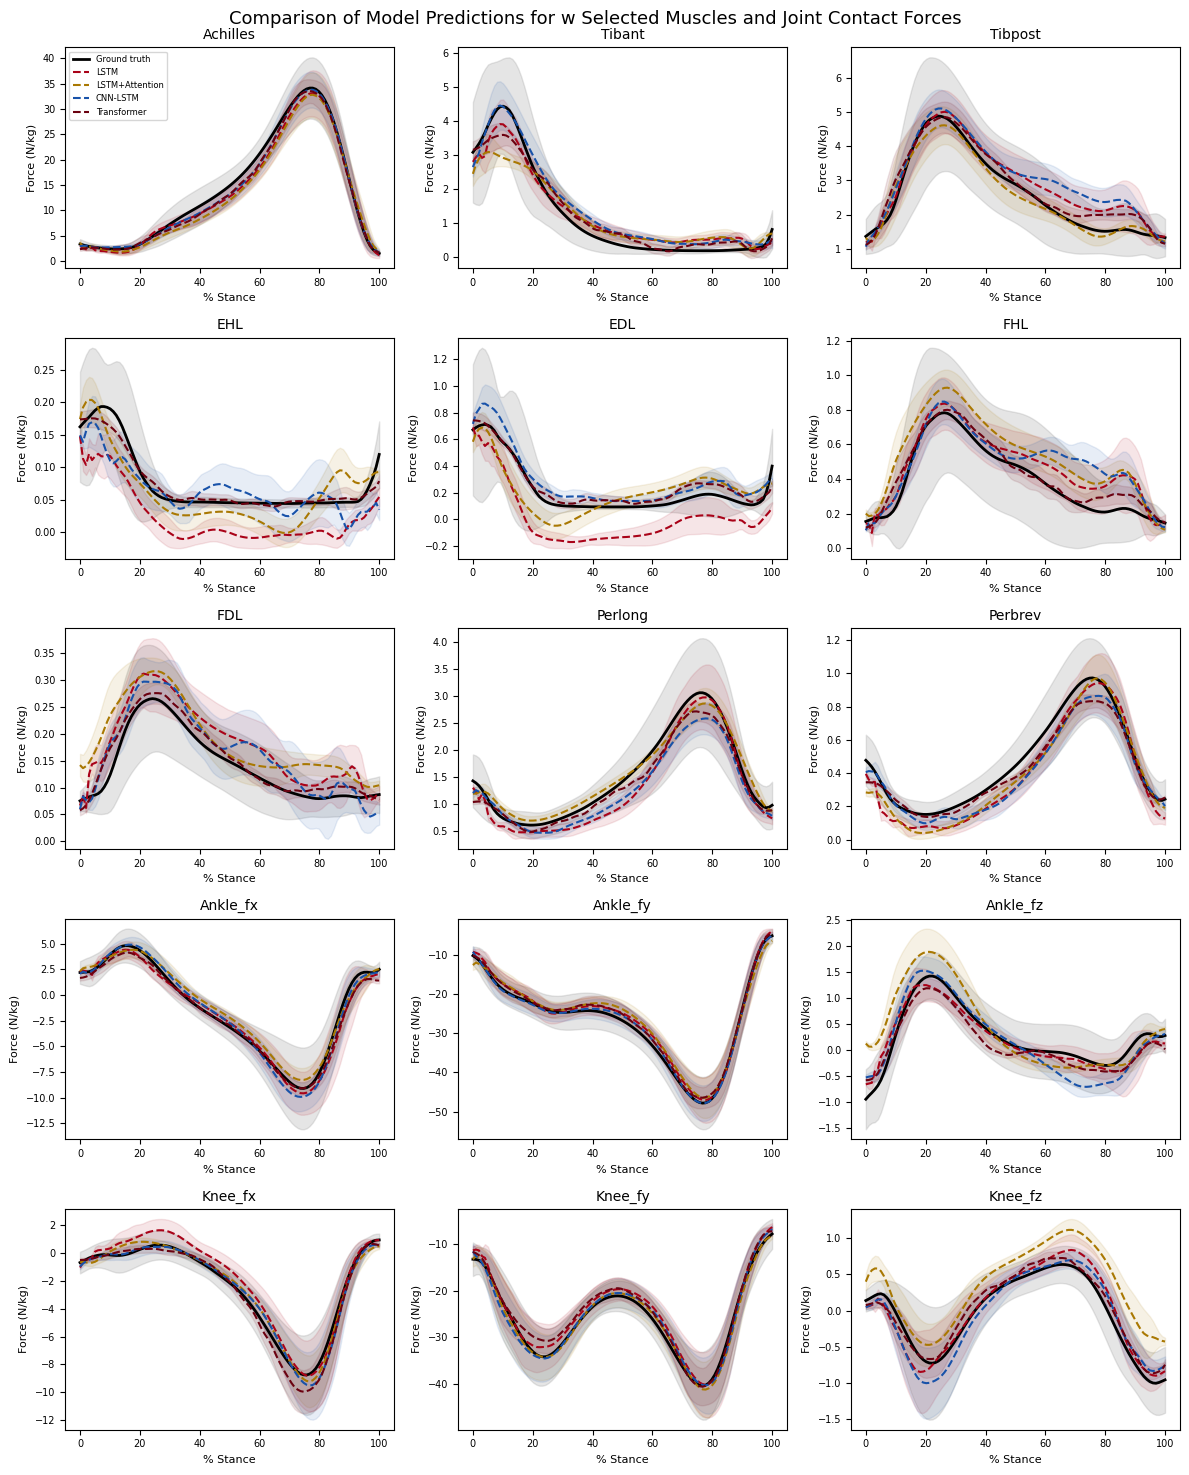

In [29]:
# MODEL_COLORS = ['#A90218', '#D4364A', '#6B0110', '#E8899A']
# # dark crimson → mid red → maroon → dusty pink


MODEL_COLORS = ['#A90218', '#A97802', '#1852A9', '#6B0110']
# crimson, amber, steel blue, maroon



perc_stance = np.linspace(0, 100, SEQ_LEN)
true_mean   = y_eval.mean(axis=0)   # (seq_len, N_EVAL)
true_std    = y_eval.std(axis=0)

pred_means = {n: p.mean(axis=0) for n, p in preds_eval.items()}
pred_stds  = {n: p.std(axis=0)  for n, p in preds_eval.items()}

ncols = 3
nrows = math.ceil(N_EVAL / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for i, lbl in enumerate(_eval_labels):
    ax = axes[i]
    ax.plot(perc_stance, true_mean[:, i], color='black', linewidth=2, label='Ground truth')
    ax.fill_between(perc_stance,
                    true_mean[:, i] - true_std[:, i],
                    true_mean[:, i] + true_std[:, i],
                    color='gray', alpha=0.2)
    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, MODEL_COLORS):
        if model_name not in pred_means:
            continue
        ax.plot(perc_stance, pred_means[model_name][:, i],
                color=color, linewidth=1.5, linestyle='--', label=label)
        ax.fill_between(perc_stance,
                        pred_means[model_name][:, i] - pred_stds[model_name][:, i],
                        pred_means[model_name][:, i] + pred_stds[model_name][:, i],
                        color=color, alpha=0.1)
    if lbl == 'ehl' or lbl == 'edl' or lbl == 'fdl' or lbl == 'fhl':
        lbl_string = str(lbl).upper()   
    else:
        lbl_string = str(lbl).capitalize()
    ax.set_title(lbl_string, fontsize=10)
    ax.set_xlabel('% Stance', fontsize=8)
    ax.set_ylabel('Force (N/kg)', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=6)

for j in range(N_EVAL, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Comparison of Model Predictions for w Selected Muscles and Joint Contact Forces', fontsize=13)
plt.tight_layout()
plt.show()

## Visualization — individual mean ± SD plots (one per output)

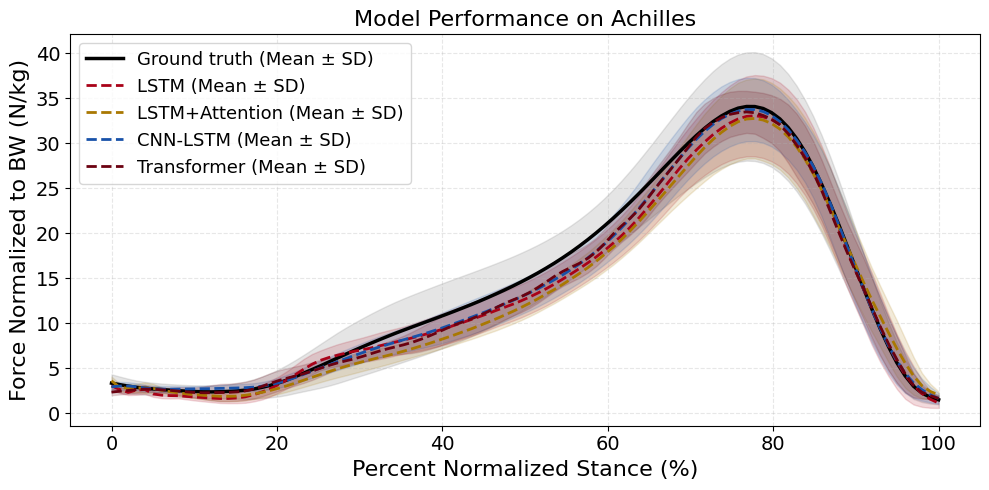

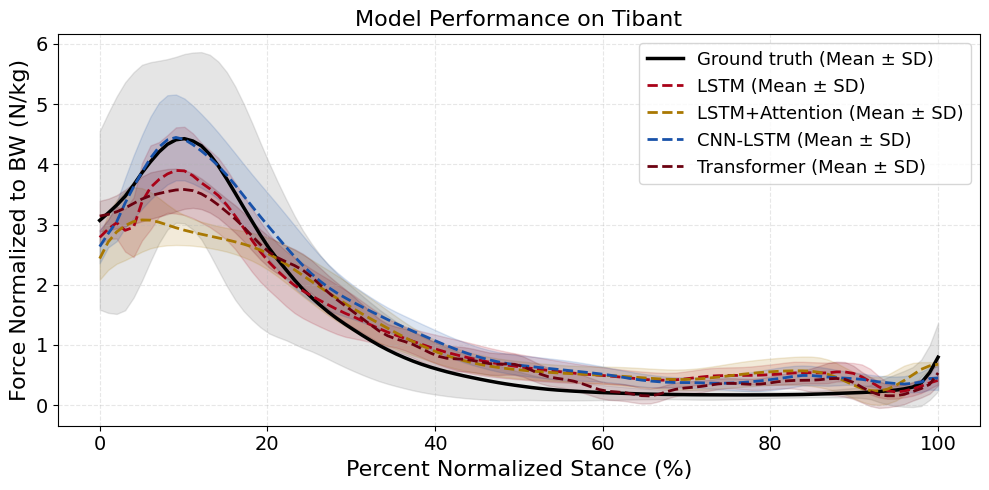

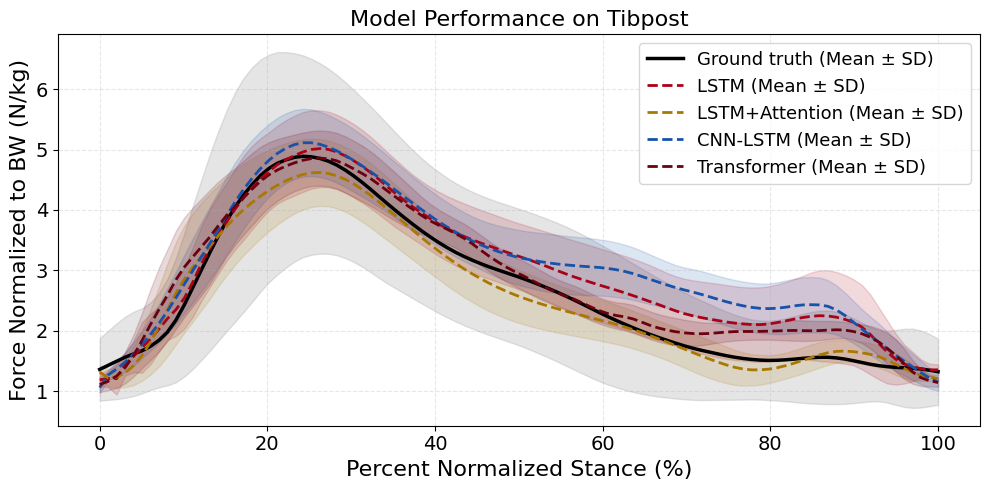

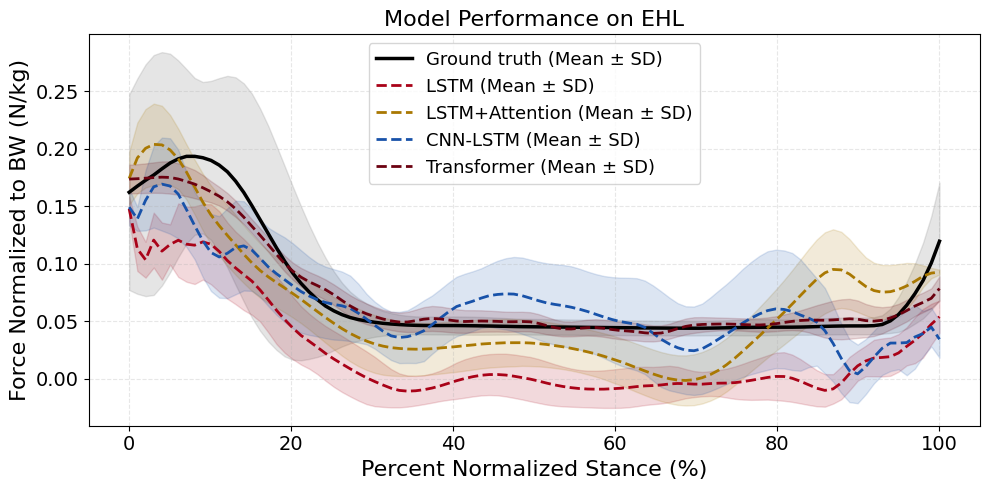

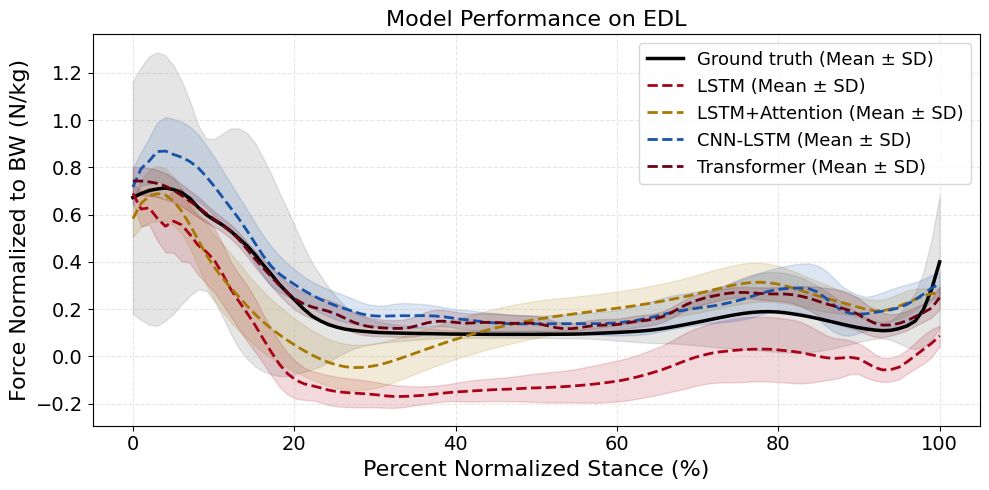

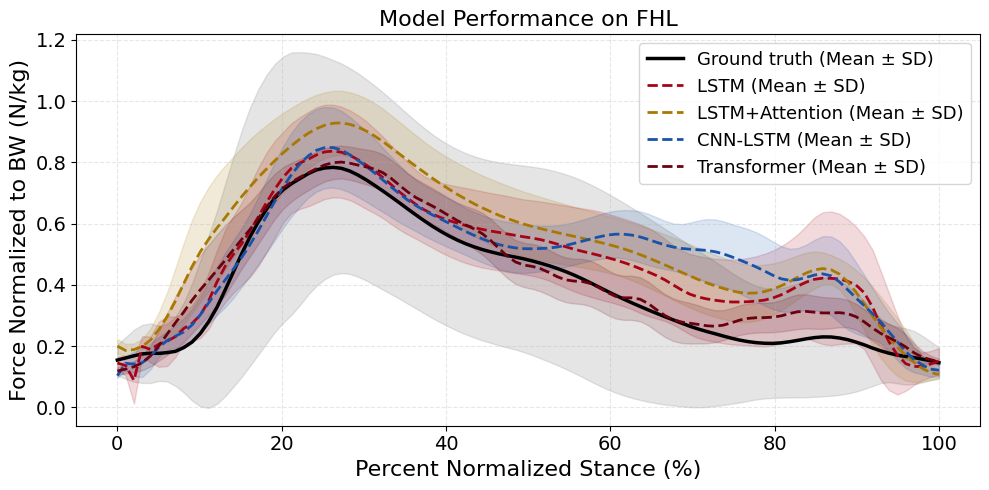

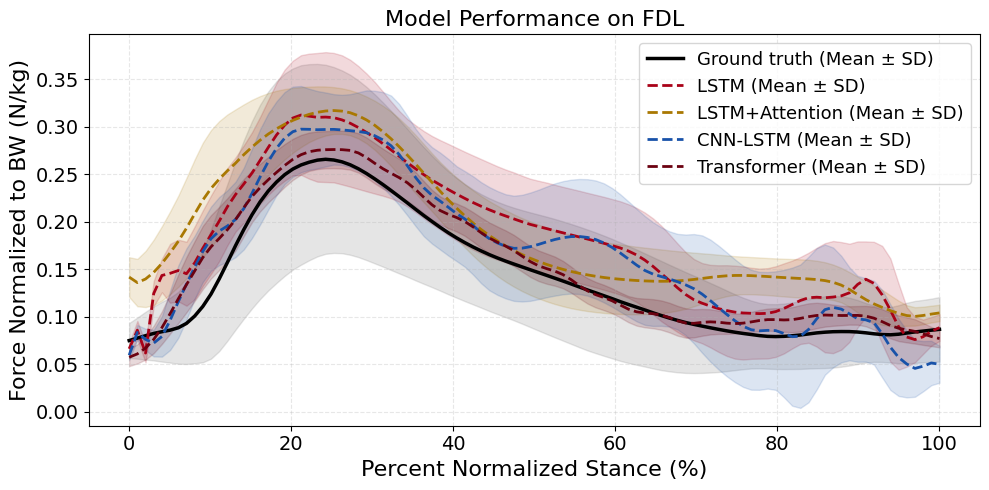

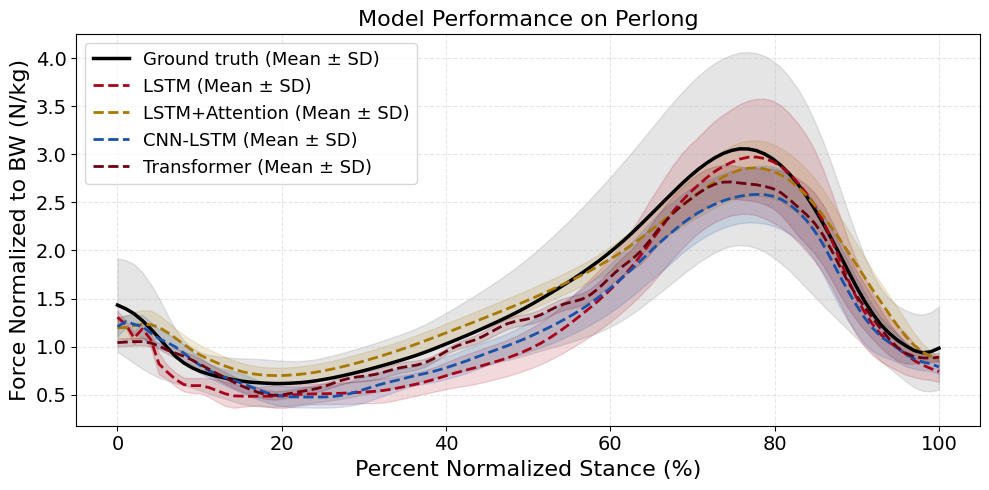

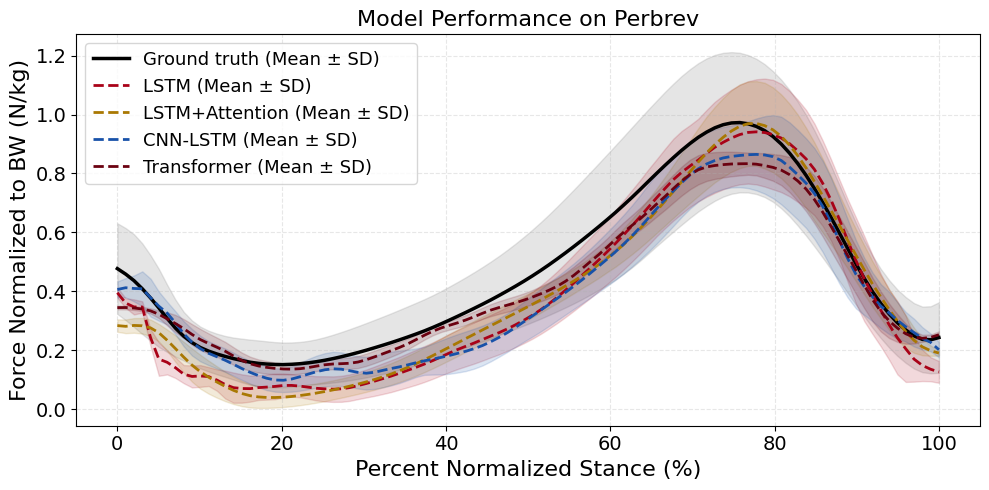

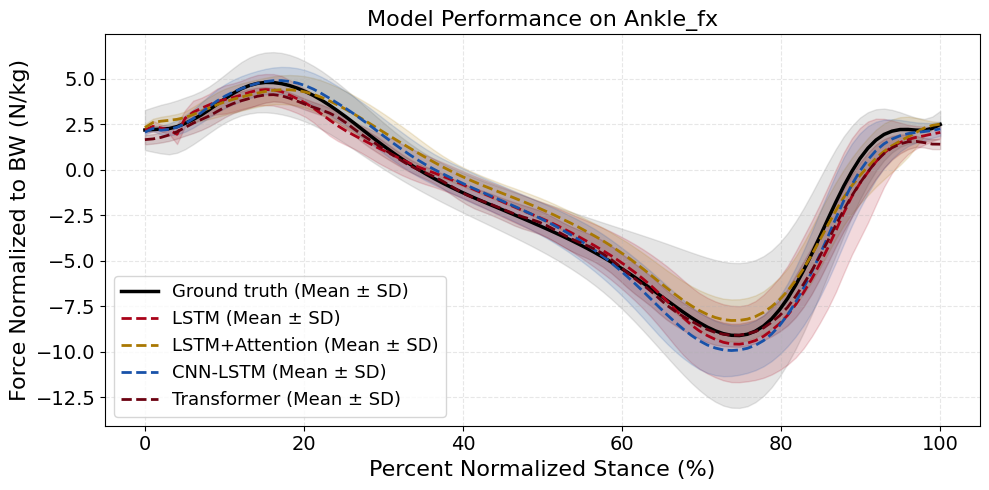

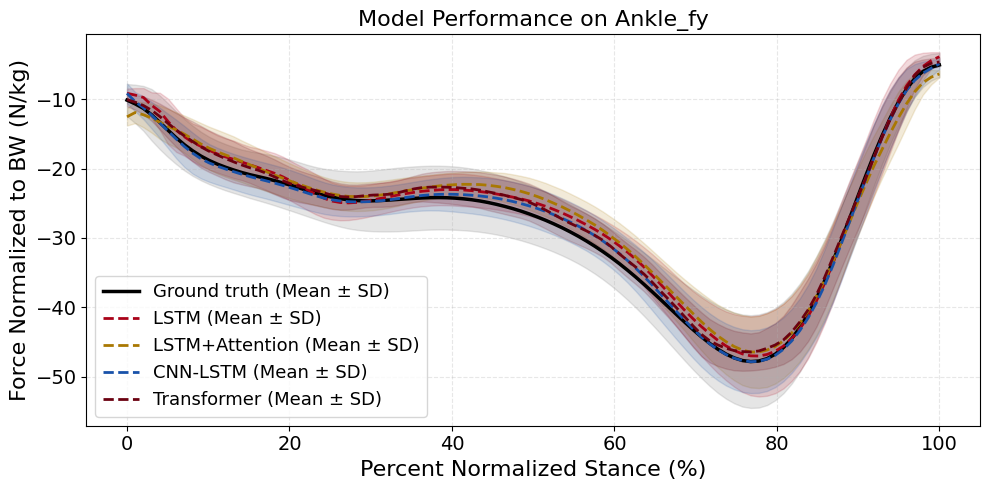

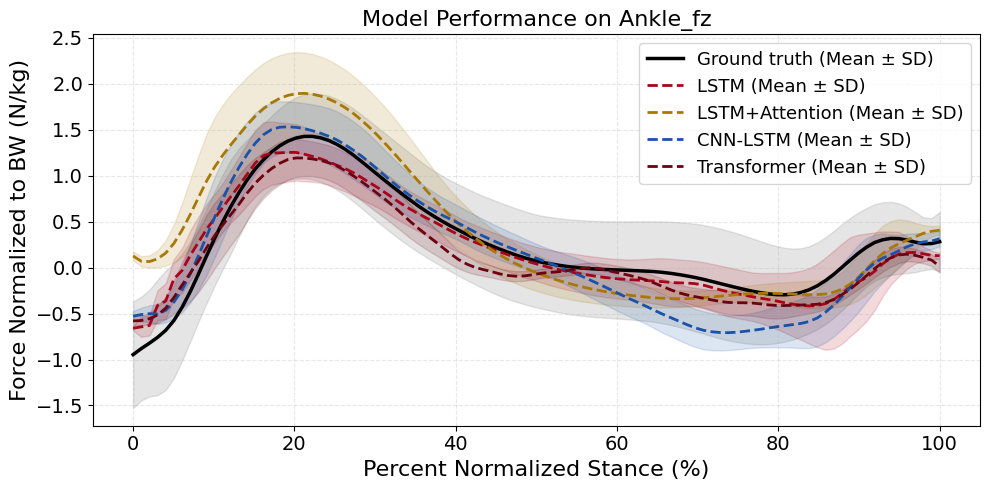

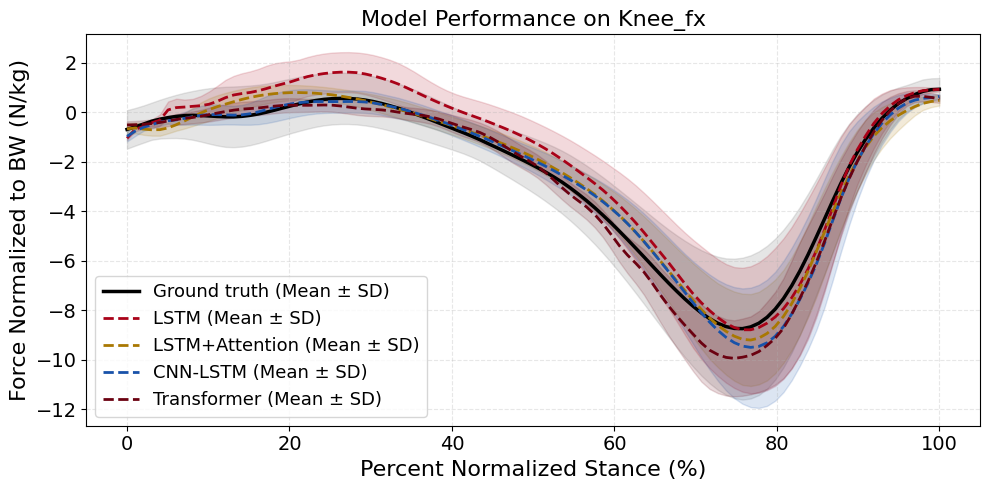

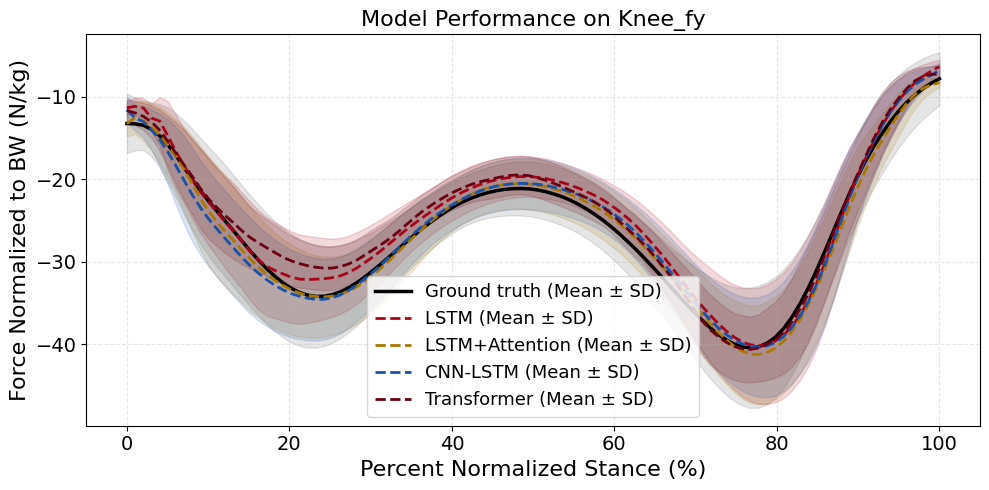

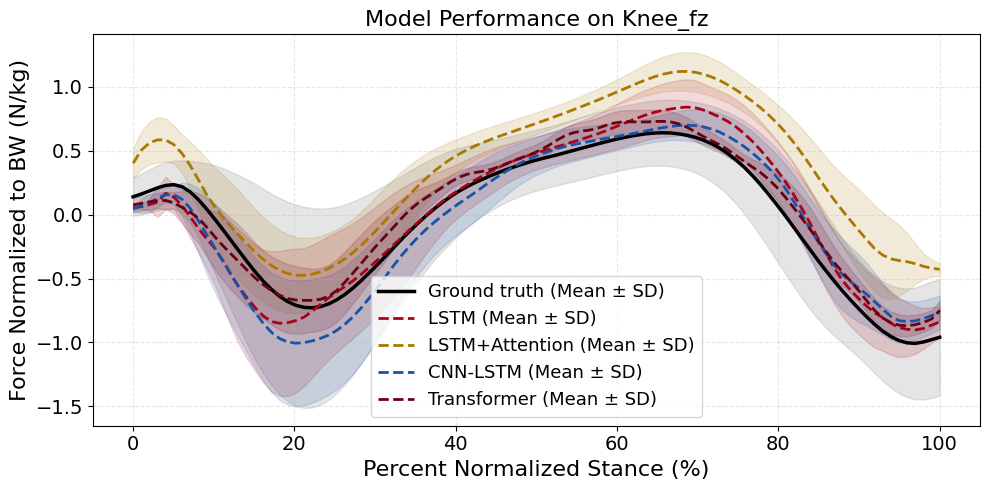

In [ ]:
for i, lbl in enumerate(_eval_labels):
    true_m = y_eval[:, :, i].mean(axis=0)
    true_s = y_eval[:, :, i].std(axis=0)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.plot(perc_stance, true_m, color='black', linewidth=2.5, label='Ground truth (Mean ± SD)')
    ax.fill_between(perc_stance, true_m - true_s, true_m + true_s, color='gray', alpha=0.2)

    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, MODEL_COLORS):
        if model_name not in preds_eval:
            continue
        pred_m = preds_eval[model_name][:, :, i].mean(axis=0)
        pred_s = preds_eval[model_name][:, :, i].std(axis=0)
        ax.plot(perc_stance, pred_m, color=color, linewidth=2, linestyle='--',
                label=f'{label} (Mean ± SD)')
        ax.fill_between(perc_stance, pred_m - pred_s, pred_m + pred_s, color=color, alpha=0.15)
    if lbl == 'ehl' or lbl == 'edl' or lbl == 'fdl' or lbl == 'fhl':
        lbl_string = str(lbl).upper()   
    else:
        lbl_string = str(lbl).capitalize()
    ax.set_title(f'Model Performance on {lbl_string}', fontsize=16)
    ax.set_xlabel('Percent Normalized Stance (%)', fontsize=16)
    ax.set_ylabel('Force Normalized to BW (N/kg)', fontsize=16)
    ax.legend(fontsize=13)
    ax.tick_params(labelsize=14)
    ax.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    #plt.savefig(f'{lbl}.svg', format='svg')
    plt.show()

## Visualization — single test sample (SAMPLE_IDX)

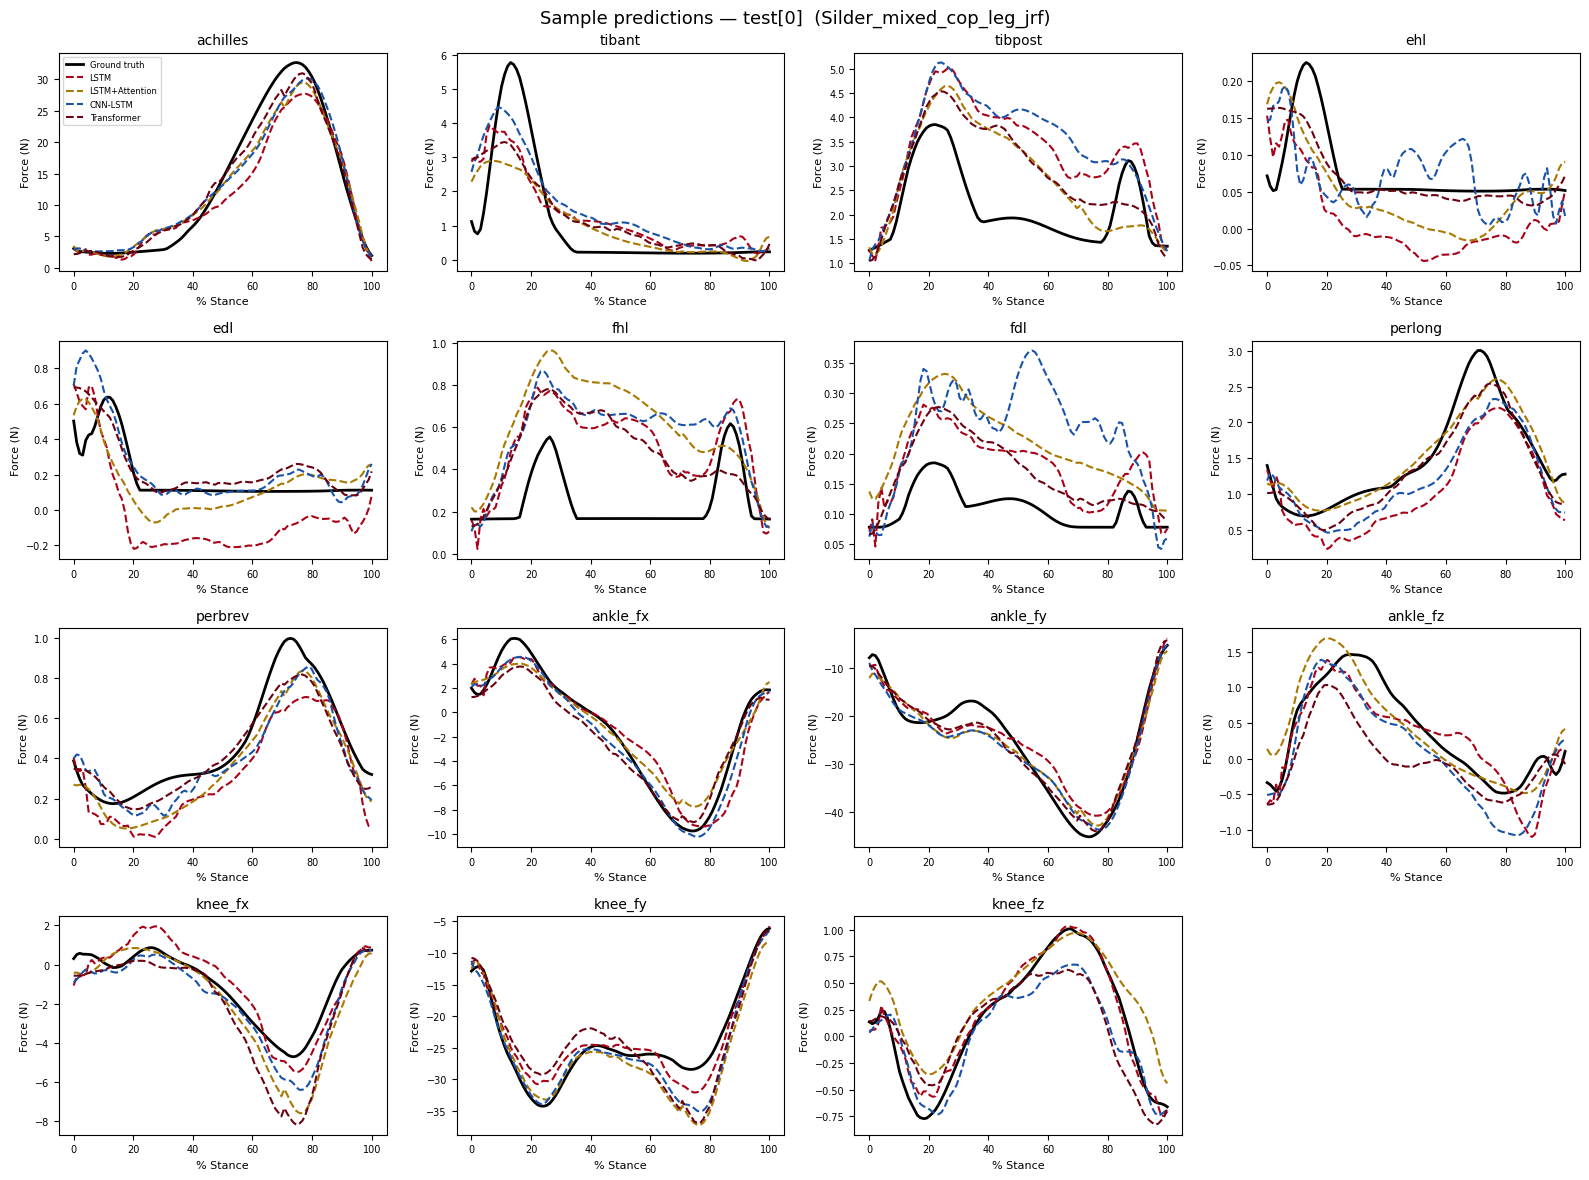

In [31]:
true_sample = y_eval[SAMPLE_IDX]   # (seq_len, N_EVAL)

ncols = 4
nrows = math.ceil(N_EVAL / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for i, lbl in enumerate(_eval_labels):
    ax = axes[i]
    ax.plot(perc_stance, true_sample[:, i], color='black', linewidth=2, label='Ground truth')
    for model_name, label, color in zip(MODELS_TO_COMPARE, MODEL_LABELS, MODEL_COLORS):
        if model_name not in preds_eval:
            continue
        ax.plot(perc_stance, preds_eval[model_name][SAMPLE_IDX, :, i],
                color=color, linewidth=1.5, linestyle='--', label=label)
    ax.set_title(lbl, fontsize=10)
    ax.set_xlabel('% Stance', fontsize=8)
    ax.set_ylabel('Force (N)', fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=6)

for j in range(N_EVAL, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Sample predictions — test[{SAMPLE_IDX}]  ({output_prefix})', fontsize=13)
plt.tight_layout()
plt.show()

## Bar charts — per-output metrics

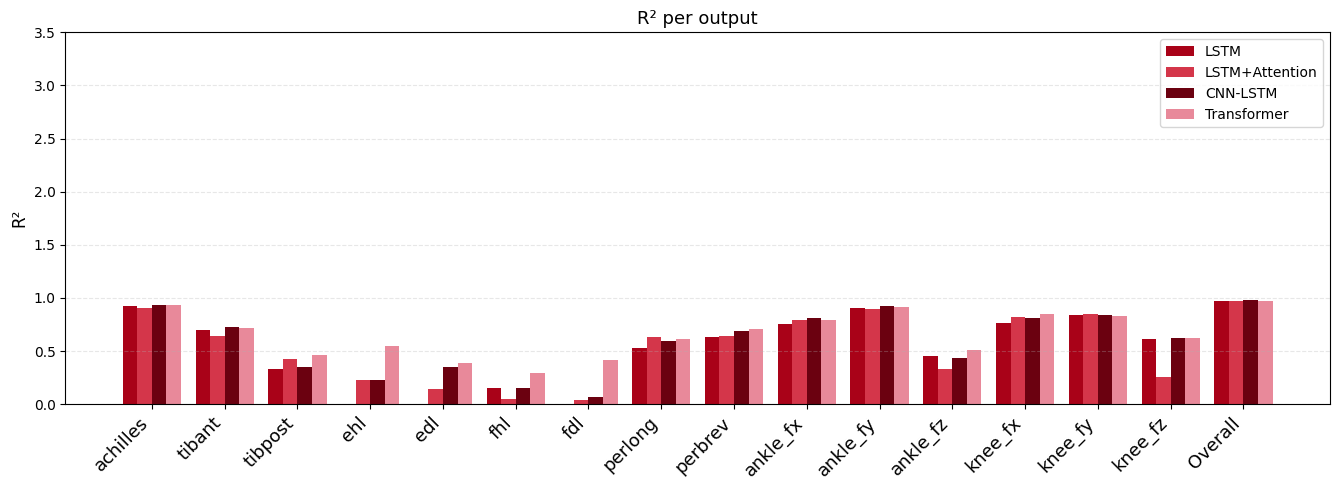

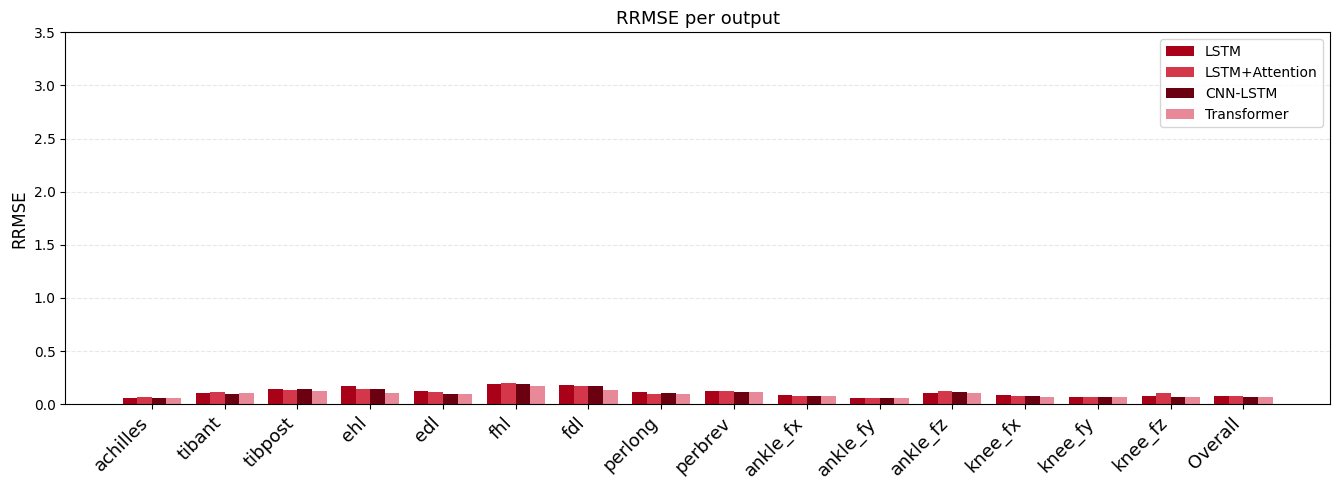

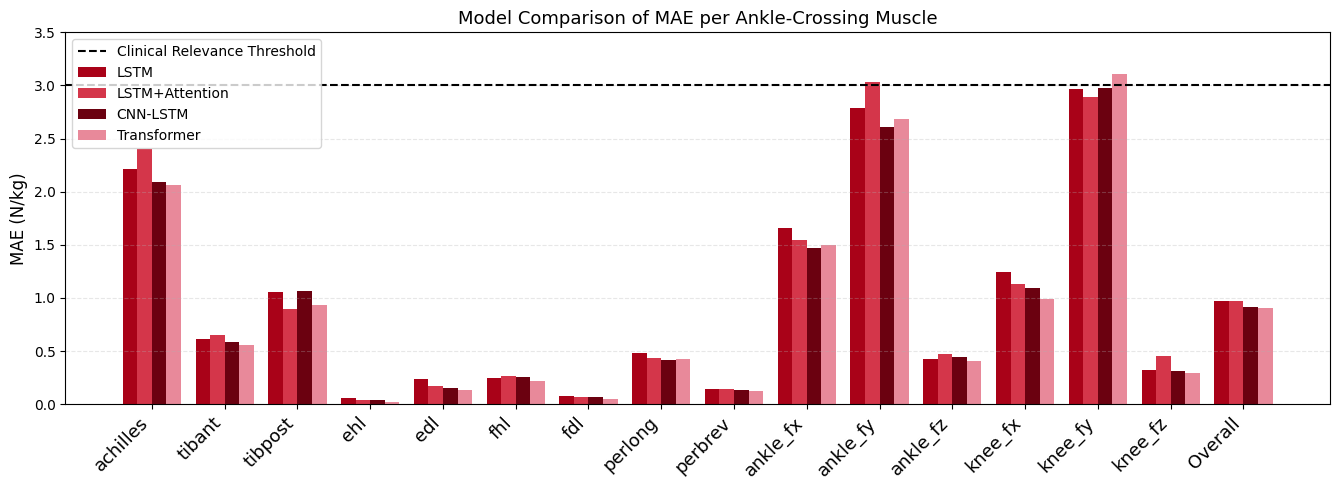

In [32]:
MODEL_COLORS = ['#A90218', '#D4364A', '#6B0110', '#E8899A']
# dark crimson → mid red → maroon → dusty pink
def _bar_chart(metric_key, ylabel, title, ylim=None, threshold=None, save_path=None):
    models_present = [n for n in MODELS_TO_COMPARE if n in per_output]
    labels_present = [MODEL_LABELS[MODELS_TO_COMPARE.index(n)] for n in models_present]
    colors_present = [MODEL_COLORS[MODELS_TO_COMPARE.index(n)] for n in models_present]

    vals_per_out = np.array([per_output[n][metric_key] for n in models_present])   # (m, N_EVAL)

    if metric_key == 'rrmse':
        vals_overall = np.array([overall[n]['rrmse_w'] for n in models_present])
    elif metric_key == 'mae':
        vals_overall = np.array([overall[n]['mae'] for n in models_present])
    else:
        vals_overall = np.array([overall[n]['r2'] for n in models_present])

    all_vals = np.hstack([vals_per_out, vals_overall.reshape(-1, 1)])  # (m, N_EVAL+1)
    x        = np.arange(N_EVAL + 1)
    bar_w    = 0.8 / len(models_present)
    offsets  = np.arange(len(models_present)) * bar_w - (len(models_present) - 1) * bar_w / 2

    fig, ax = plt.subplots(figsize=(max(12, N_EVAL * 0.9), 5))
    for label, color, offset, row in zip(labels_present, colors_present, offsets, all_vals):
        ax.bar(x + offset, row, width=bar_w, label=label, color=color)

    if threshold is not None:
        ax.axhline(threshold, color='black', linewidth=1.5, linestyle='--',
                   label=f'Clinical Relevance Threshold')

    ax.set_xticks(x)
    ax.set_xticklabels(list(_eval_labels) + ['Overall'], rotation=45, ha='right', fontsize=13)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13)
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_ylim([0,3.5])
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, format='svg')
    plt.show()


_bar_chart('r2',    'R²',         'R² per output',    ylim=(None, 1.0))
_bar_chart('rrmse', 'RRMSE',      'RRMSE per output')
_bar_chart('mae',   'MAE (N/kg)', 'Model Comparison of MAE per Ankle-Crossing Muscle',
           threshold=3.0, save_path=f'{output_prefix}_mae_per_output.svg')

## LaTeX tables

In [33]:
def generate_latex_table(metric_key, caption=''):
    """Rows = outputs in _eval_labels, columns = models. Last row = overall."""
    models_present = [n for n in MODELS_TO_COMPARE if n in per_output]
    labels_present = [MODEL_LABELS[MODELS_TO_COMPARE.index(n)] for n in models_present]

    col_spec = 'l' + 'c' * len(models_present)
    header   = ' & '.join([f'\\textbf{{{lbl}}}' for lbl in labels_present])

    lines = [
        '\\begin{table}', '\\centering',
        f'\\begin{{tabular}}{{{col_spec}}}',
        '\\toprule',
        f'\\textbf{{Output}} & {header} \\\\',
        '\\midrule',
    ]

    for i, lbl in enumerate(_eval_labels):
        row = ' & '.join([f'{per_output[n][metric_key][i]:.4f}' for n in models_present])
        lines.append(f'{lbl} & {row} \\\\')

    lines.append('\\midrule')

    if metric_key == 'rrmse':
        ov = {n: overall[n]['rrmse_w'] for n in models_present}
    elif metric_key == 'mae':
        ov = {n: overall[n]['mae'] for n in models_present}
    else:
        ov = {n: overall[n]['r2'] for n in models_present}

    ov_row = ' & '.join([f'{ov[n]:.4f}' for n in models_present])
    lines.append(f'Overall & {ov_row} \\\\')
    lines += [
        '\\bottomrule',
        f'\\end{{tabular}}',
        f'\\caption{{{caption}}}',
        '\\label{tab:' + metric_key + '}',
        '\\end{table}',
    ]
    return '\n'.join(lines)


print('=== RRMSE table ===')
print(generate_latex_table('rrmse', caption='RRMSE per output across models.'))
print()
print('=== MAE table ===')
print(generate_latex_table('mae',   caption='MAE (N/kg) per output across models.'))
print()
print('=== R² table ===')
print(generate_latex_table('r2',    caption='R² per output across models.'))

=== RRMSE table ===
\begin{table}
\centering
\begin{tabular}{lcccc}
\toprule
\textbf{Output} & \textbf{LSTM} & \textbf{LSTM+Attention} & \textbf{CNN-LSTM} & \textbf{Transformer} \\
\midrule
achilles & 0.0626 & 0.0685 & 0.0592 & 0.0589 \\
tibant & 0.1037 & 0.1139 & 0.0995 & 0.1014 \\
tibpost & 0.1412 & 0.1306 & 0.1389 & 0.1261 \\
ehl & 0.1720 & 0.1451 & 0.1445 & 0.1103 \\
edl & 0.1289 & 0.1107 & 0.0964 & 0.0936 \\
fhl & 0.1904 & 0.2011 & 0.1900 & 0.1729 \\
fdl & 0.1788 & 0.1721 & 0.1697 & 0.1350 \\
perlong & 0.1116 & 0.0984 & 0.1028 & 0.1011 \\
perbrev & 0.1269 & 0.1244 & 0.1164 & 0.1135 \\
ankle_fx & 0.0846 & 0.0779 & 0.0751 & 0.0773 \\
ankle_fy & 0.0582 & 0.0631 & 0.0543 & 0.0566 \\
ankle_fz & 0.1102 & 0.1217 & 0.1117 & 0.1042 \\
knee_fx & 0.0887 & 0.0785 & 0.0794 & 0.0703 \\
knee_fy & 0.0675 & 0.0662 & 0.0686 & 0.0710 \\
knee_fz & 0.0738 & 0.1021 & 0.0728 & 0.0723 \\
\midrule
Overall & 0.0758 & 0.0767 & 0.0719 & 0.0716 \\
\bottomrule
\end{tabular}
\caption{RRMSE per output across mod

## Integrated Gradients — input feature attribution

lstm: IG done  shape=(15, 100, 6)
lstm_attn: IG done  shape=(15, 100, 6)
cnn_lstm: IG done  shape=(15, 100, 6)
transformer: IG done  shape=(15, 100, 6)


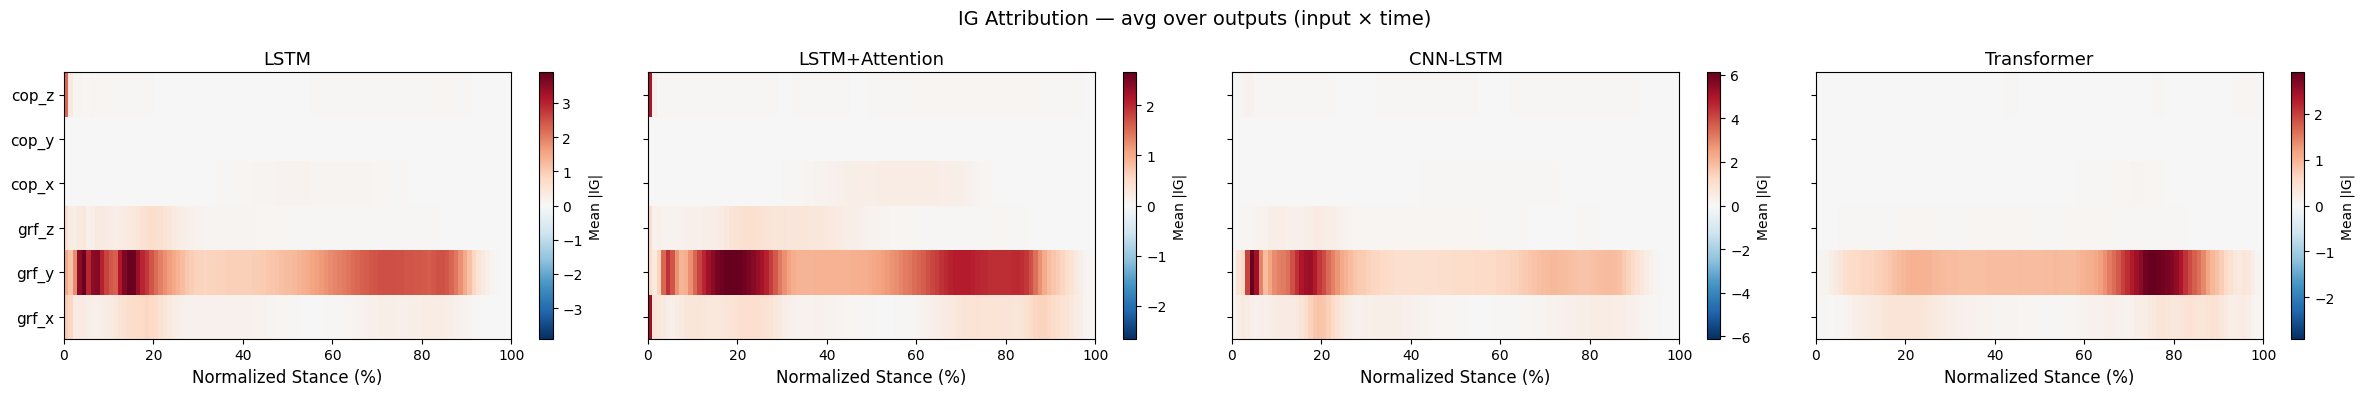

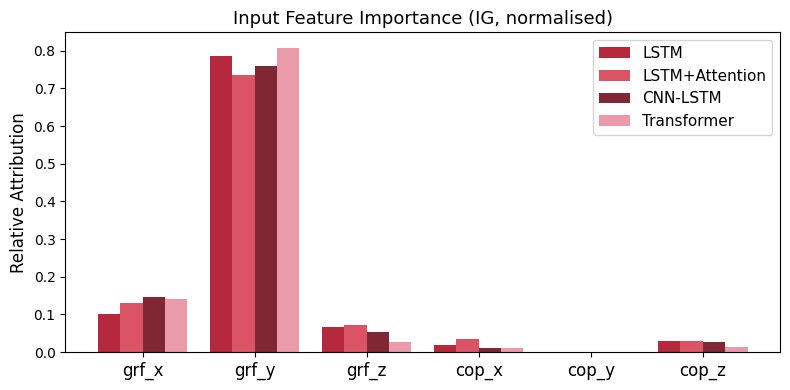

In [34]:
def integrated_gradients(model, x, target_out_idx, n_steps=50, baseline=None):
    """
    Compute IG attributions for one output channel across all input features.

    Parameters
    ----------
    model          : nn.Module (eval mode, on device)
    x              : (1, seq_len, n_inputs) float32 tensor, requires_grad=False
    target_out_idx : int — which output to attribute (index into OUTPUT_KEYS)
    n_steps        : number of Riemann steps along interpolation path
    baseline       : same shape as x; defaults to zeros (all-zero GRF/COP)

    Returns
    -------
    attrs : (seq_len, n_inputs) ndarray — signed attribution per timestep/feature
    """
    if baseline is None:
        baseline = torch.zeros_like(x)

    grads = []
    for step in range(n_steps + 1):
        alpha = step / n_steps
        interp = (baseline + alpha * (x - baseline)).requires_grad_(True)
        out = model(interp)                         # (1, seq_len, n_outputs)
        scalar = out[0, :, target_out_idx].sum()   # sum over time → scalar
        scalar.backward()
        grads.append(interp.grad.detach().cpu().squeeze(0).numpy())  # (seq_len, n_inputs)

    avg_grads = np.mean(grads, axis=0)             # (seq_len, n_inputs)
    delta = (x - baseline).detach().cpu().squeeze(0).numpy()
    return avg_grads * delta                       # element-wise product


def batch_ig(model, X_tensor, target_out_idx, n_steps=50, max_samples=200):
    """
    Average IG attributions across up to max_samples test examples.
    Returns (seq_len, n_inputs) mean absolute attribution.
    """
    model.eval()
    n = min(len(X_tensor), max_samples)
    attrs = []
    for i in range(n):
        x = X_tensor[i:i+1]   # keep batch dim
        attrs.append(integrated_gradients(model, x, target_out_idx, n_steps))
    return np.mean(np.abs(attrs), axis=0)  # (seq_len, n_inputs)


# ── Run IG for every model × every eval output ────────────────────────────────
# Set IG_OUTPUTS to a subset of _eval_labels to save time, or None for all.
IG_OUTPUTS = None   # e.g. ['achilles', 'soleus', 'gaslat'] or None for all
IG_STEPS   = 50
IG_SAMPLES = 200

ig_out_labels = _eval_labels if IG_OUTPUTS is None else IG_OUTPUTS
ig_out_idxs   = [_eval_labels.index(l) for l in ig_out_labels]

ig_results = {}   # {model_name: (n_outputs, seq_len, n_inputs)}

for model_name in MODELS_TO_COMPARE:
    if model_name not in test_results:
        continue
    model = test_results[model_name]['model'].eval()
    attrs_all = []
    for out_idx in ig_out_idxs:
        a = batch_ig(model, X_test_t, out_idx, n_steps=IG_STEPS, max_samples=IG_SAMPLES)
        attrs_all.append(a)
    ig_results[model_name] = np.stack(attrs_all)  # (n_eval_outputs, seq_len, n_inputs)
    print(f'{model_name}: IG done  shape={ig_results[model_name].shape}')


# ── Plot 1: per-model heatmap (input feature × time, averaged over outputs) ──
# Rows = INPUT_KEYS, Cols = % stance.  One subplot per model.
n_models = len(ig_results)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (model_name, attrs) in zip(axes, ig_results.items()):
    mean_attr = attrs.mean(axis=0).T   # (n_inputs, seq_len)
    im = ax.imshow(
        mean_attr,
        aspect='auto',
        origin='lower',
        cmap='RdBu_r',
        vmin=-np.abs(mean_attr).max(),
        vmax= np.abs(mean_attr).max(),
        extent=[0, 100, -0.5, len(INPUT_KEYS) - 0.5],
    )
    ax.set_yticks(range(len(INPUT_KEYS)))
    ax.set_yticklabels(INPUT_KEYS, fontsize=11)
    ax.set_xlabel('Normalized Stance (%)', fontsize=12)
    ax.set_title(MODEL_LABELS[MODELS_TO_COMPARE.index(model_name)], fontsize=13)
    plt.colorbar(im, ax=ax, label='Mean |IG|')

fig.suptitle('IG Attribution — avg over outputs (input × time)', fontsize=14)
plt.tight_layout()
plt.show()


# ── Plot 2: per-input bar chart — total attribution per feature per model ─────
# Collapses time axis: sum |IG| over stance, then average over outputs.
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(INPUT_KEYS))
bar_w = 0.8 / len(ig_results)

for k, (model_name, attrs) in enumerate(ig_results.items()):
    feat_importance = np.abs(attrs).sum(axis=1).mean(axis=0)   # (n_inputs,)
    feat_importance /= feat_importance.sum()                    # normalise to sum=1
    color = MODEL_COLORS[MODELS_TO_COMPARE.index(model_name)]
    label = MODEL_LABELS[MODELS_TO_COMPARE.index(model_name)]
    ax.bar(x_pos + k * bar_w, feat_importance, bar_w, label=label, color=color, alpha=0.85)

ax.set_xticks(x_pos + bar_w * (len(ig_results) - 1) / 2)
ax.set_xticklabels(INPUT_KEYS, fontsize=12)
ax.set_ylabel('Relative Attribution', fontsize=12)
ax.set_title('Input Feature Importance (IG, normalised)', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## Integrated Gradients — deeper analysis

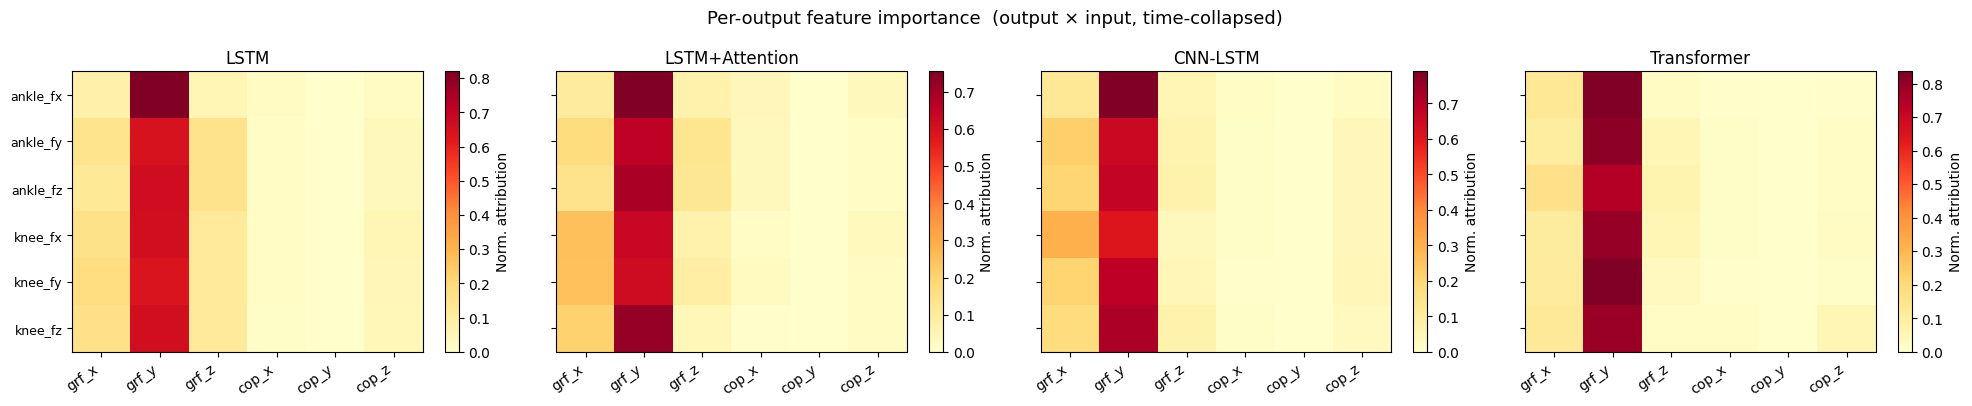

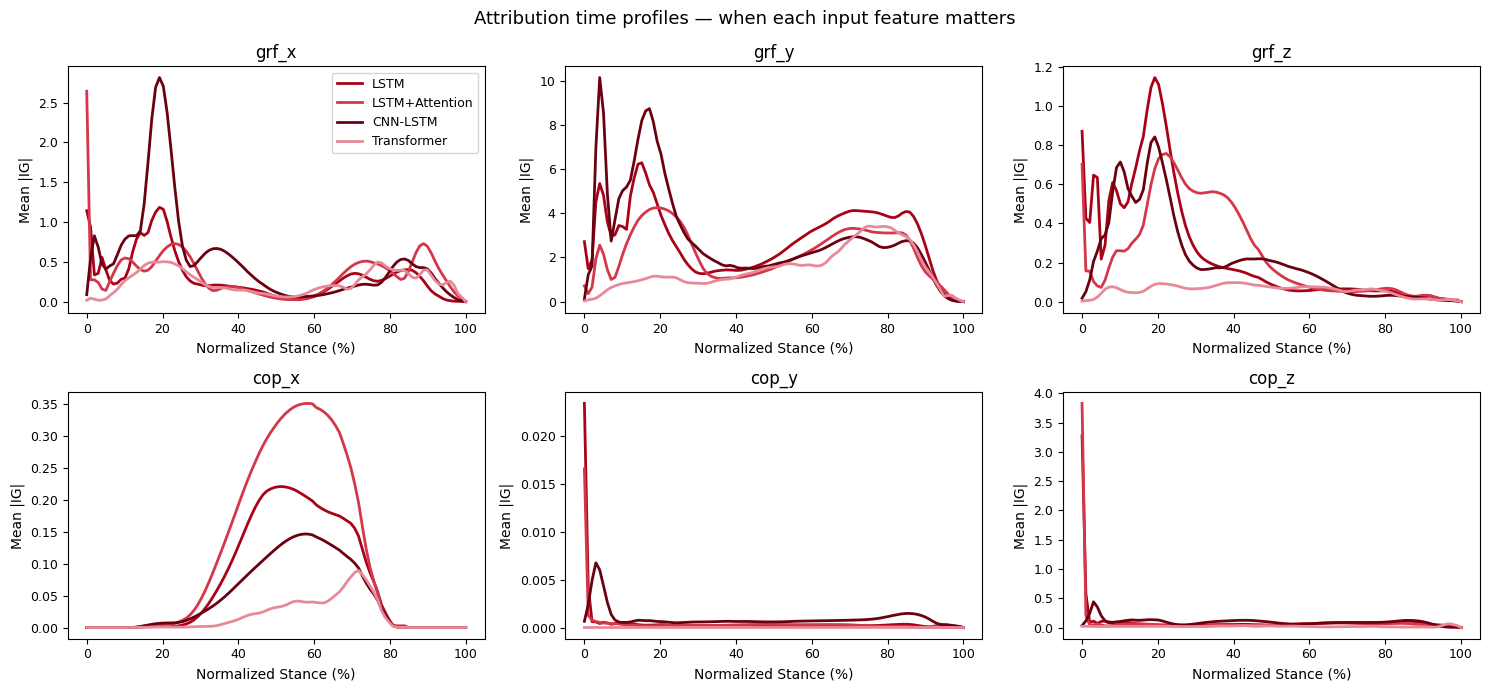

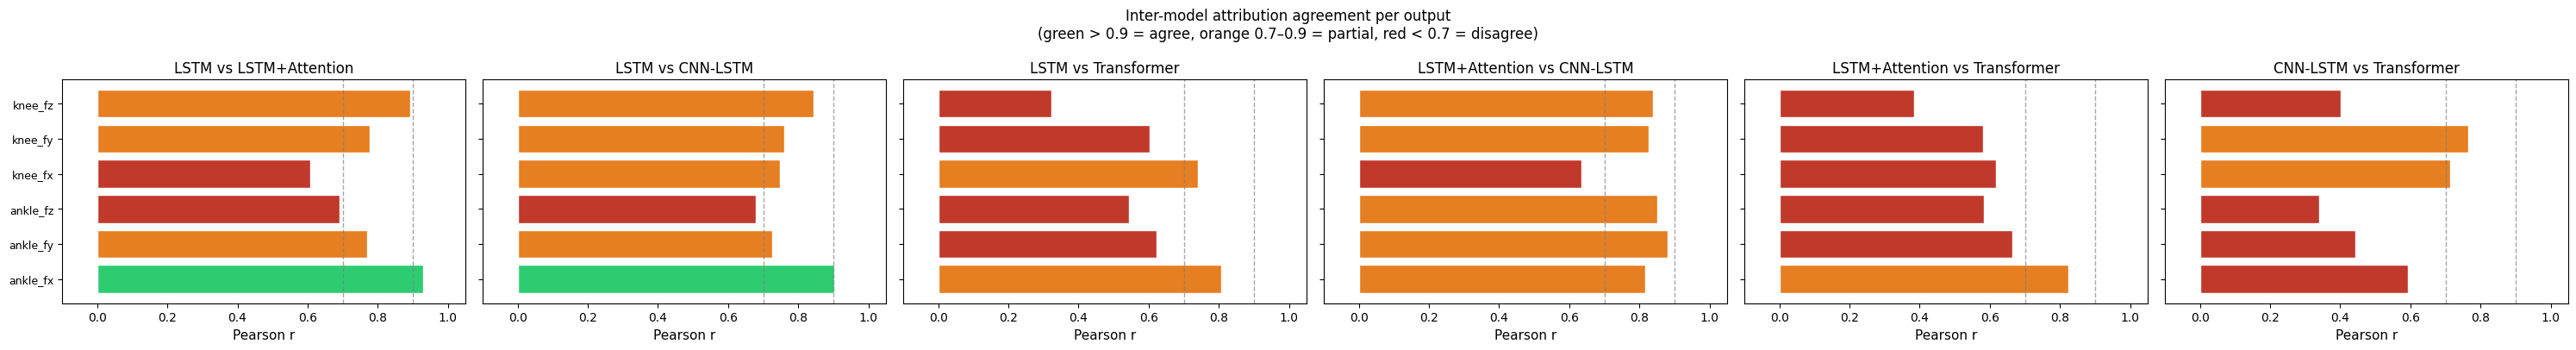

In [18]:
# ── Plot 3: per-output feature importance heatmap ────────────────────────────
# Rows = eval outputs (muscles), Cols = input features.
# Each cell = mean |IG| summed over time, for that output × feature pair.
# One subplot per model — reveals which inputs drive which muscles.

n_models = len(ig_results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 0.35 * len(ig_out_labels) + 2),
                         sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (model_name, attrs) in zip(axes, ig_results.items()):
    # attrs: (n_eval_outputs, seq_len, n_inputs)
    feat_by_output = np.abs(attrs).sum(axis=1)        # (n_outputs, n_inputs)
    feat_by_output /= feat_by_output.sum(axis=1, keepdims=True)  # normalise per output

    im = ax.imshow(feat_by_output, aspect='auto', cmap='YlOrRd',
                   vmin=0, vmax=feat_by_output.max())
    ax.set_xticks(range(len(INPUT_KEYS)))
    ax.set_xticklabels(INPUT_KEYS, rotation=35, ha='right', fontsize=10)
    ax.set_yticks(range(len(ig_out_labels)))
    ax.set_yticklabels(ig_out_labels, fontsize=9)
    ax.set_title(MODEL_LABELS[MODELS_TO_COMPARE.index(model_name)], fontsize=12)
    plt.colorbar(im, ax=ax, label='Norm. attribution')

fig.suptitle('Per-output feature importance  (output × input, time-collapsed)', fontsize=13)
plt.tight_layout()
plt.show()


# ── Plot 4: attribution time profiles per input feature ───────────────────────
# One subplot per input feature. Each line = one model, averaged over outputs.
# Shows *when* during stance each feature is relied upon.

ncols = 3
nrows = math.ceil(len(INPUT_KEYS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), sharey=False)
axes = axes.flatten()

for feat_idx, feat_name in enumerate(INPUT_KEYS):
    ax = axes[feat_idx]
    for model_name, attrs in ig_results.items():
        # mean |IG| over outputs at each timestep for this feature
        profile = np.abs(attrs[:, :, feat_idx]).mean(axis=0)  # (seq_len,)
        color = MODEL_COLORS[MODELS_TO_COMPARE.index(model_name)]
        label = MODEL_LABELS[MODELS_TO_COMPARE.index(model_name)]
        ax.plot(perc_stance, profile, color=color, linewidth=2, label=label)

    ax.set_title(feat_name, fontsize=12)
    ax.set_xlabel('Normalized Stance (%)', fontsize=10)
    ax.set_ylabel('Mean |IG|', fontsize=10)
    ax.tick_params(labelsize=9)
    if feat_idx == 0:
        ax.legend(fontsize=9)

for ax in axes[len(INPUT_KEYS):]:
    ax.set_visible(False)

fig.suptitle('Attribution time profiles — when each input feature matters', fontsize=13)
plt.tight_layout()
plt.show()


# ── Plot 5: inter-model attribution agreement ─────────────────────────────────
# Per output: Pearson r between model A and model B attribution vectors
# (flattened seq_len × n_inputs). Low r = same accuracy, different strategy.

from itertools import combinations
from scipy.stats import pearsonr

model_names = list(ig_results.keys())
pairs = list(combinations(model_names, 2))

if len(pairs) > 0:
    fig, axes = plt.subplots(1, len(pairs),
                             figsize=(5 * len(pairs), 0.35 * len(ig_out_labels) + 2),
                             sharey=True)
    if len(pairs) == 1:
        axes = [axes]

    for ax, (m1, m2) in zip(axes, pairs):
        r_vals = []
        for out_idx in range(len(ig_out_labels)):
            v1 = ig_results[m1][out_idx].ravel()
            v2 = ig_results[m2][out_idx].ravel()
            r, _ = pearsonr(v1, v2)
            r_vals.append(r)

        r_vals = np.array(r_vals)
        colors = ['#c0392b' if r < 0.7 else '#2ecc71' if r > 0.9 else '#e67e22'
                  for r in r_vals]
        ax.barh(range(len(ig_out_labels)), r_vals, color=colors, edgecolor='white')
        ax.axvline(0.7, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.axvline(0.9, color='gray', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_xlim([-0.1, 1.05])
        ax.set_yticks(range(len(ig_out_labels)))
        ax.set_yticklabels(ig_out_labels, fontsize=9)
        ax.set_xlabel('Pearson r', fontsize=11)
        l1 = MODEL_LABELS[MODELS_TO_COMPARE.index(m1)]
        l2 = MODEL_LABELS[MODELS_TO_COMPARE.index(m2)]
        ax.set_title(f'{l1} vs {l2}', fontsize=12)

    fig.suptitle('Inter-model attribution agreement per output\n'
                 '(green > 0.9 = agree, orange 0.7–0.9 = partial, red < 0.7 = disagree)',
                 fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print('Need at least 2 models to compare attribution agreement.')
